In [ ]:
# ── CELL 1: Install ──────────────

import subprocess, sys

def pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

# Step 1: Core ML — fast, pre-built wheels
pip(["scikit-learn", "xgboost", "lightgbm", "catboost",
     "imbalanced-learn", "pandas", "numpy", "matplotlib",
     "seaborn", "joblib", "tqdm"])

# Step 2: Transformers stack — pre-built
pip(["transformers==4.40.0", "datasets", "accelerate", "sentencepiece"])

# Step 3: PyTorch — already installed on Colab, just verify
import torch
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

# Step 4: torch-geometric ONLY — skip scatter/sparse (not needed for our GCN)
# Use the pure-Python pyg-lib fallback instead
pip(["torch_geometric"])

# torch-geometric can run without torch-scatter/torch-sparse
# by using its built-in pure-Python fallbacks for GCNConv
# DO NOT install torch-scatter or torch-sparse — they cause the hang

print("✅ All dependencies installed ")

PyTorch: 2.11.0+cu128 | CUDA: True
✅ All dependencies installed 


In [ ]:
# ── CELL 2: Imports ───────────────────────────────────────────
import os, re, json, ast, hashlib, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

✅ Using device: cuda


In [ ]:
# ── CELL 3: Synthetic CVE Dataset Builder ─────────────────────
# Generates realistic C/C++ code snippets labelled by CWE type.
# Replace with real BigVul / Devign dataset in production.

VULN_TEMPLATES = {
    "CWE-119_BufferOverflow": [
        '''void copy_data(char *dst, char *src) {{
    char buf[{sz}];
    strcpy(buf, src);  // {comment}
    memcpy(dst, buf, strlen(src));
}}''',
        '''int process_input(char *input) {{
    char buffer[{sz}];
    gets(buffer);  // {comment}
    return strlen(buffer);
}}''',
    ],
    "CWE-89_SQLInjection": [
        '''void query_db(char *user_input) {{
    char query[512];
    sprintf(query, "SELECT * FROM users WHERE name='%s'", user_input);  // {comment}
    db_execute(query);
}}''',
        '''std::string build_query(std::string username) {{
    return "SELECT id FROM accounts WHERE user=" + username;  // {comment}
}}''',
    ],
    "CWE-416_UseAfterFree": [
        '''void handle_request(Request *req) {{
    char *data = malloc({sz});
    process(data);
    free(data);
    log_data(data);  // {comment}
}}''',
        '''Object* get_object(int id) {{
    Object *obj = cache_get(id);
    cache_remove(id);
    return obj;  // {comment} — object may be freed
}}''',
    ],
    "CWE-78_CommandInjection": [
        '''void run_command(char *user_cmd) {{
    char cmd[256];
    snprintf(cmd, sizeof(cmd), "ls %s", user_cmd);  // {comment}
    system(cmd);
}}''',
    ],
    "CWE-125_OutOfBoundsRead": [
        '''int read_element(int *arr, int idx, int len) {{
    return arr[idx];  // {comment} — no bounds check
}}''',
    ],
    "SAFE": [
        '''void safe_copy(char *dst, const char *src, size_t dst_size) {{
    if (!dst || !src) return;
    strncpy(dst, src, dst_size - 1);
    dst[dst_size - 1] = '\\0';
}}''',
        '''std::string safe_query(const std::string& user_id) {{
    // Parameterized query - safe from injection
    PreparedStatement stmt = db.prepare("SELECT * FROM users WHERE id = ?");
    stmt.bind(1, sanitize(user_id));
    return stmt.execute();
}}''',
        '''int bounded_read(int *arr, int idx, int len) {{
    if (idx < 0 || idx >= len) return -1;
    return arr[idx];
}}''',
        '''void free_safe(void **ptr) {{
    if (*ptr) {{
        free(*ptr);
        *ptr = NULL;  // prevents use-after-free
    }}
}}''',
    ],
}

COMMENTS = [
    "no bounds check", "user-controlled", "potential overflow",
    "missing validation", "unchecked input", "TODO: sanitize",
    "legacy code", "FIXME: vulnerable", "size not verified",
]

def generate_synthetic_dataset(n_samples: int = 5000) -> pd.DataFrame:
    records = []
    vuln_types = list(VULN_TEMPLATES.keys())

    for _ in range(n_samples):
        cwe = random.choice(vuln_types)
        template = random.choice(VULN_TEMPLATES[cwe])
        code = template.format(
            sz=random.choice([32, 64, 128, 256, 512]),
            comment=random.choice(COMMENTS)
        )
        label = 0 if cwe == "SAFE" else 1
        cwe_id = cwe if cwe != "SAFE" else "SAFE"
        records.append({
            "code": code,
            "label": label,
            "cwe": cwe_id,
            "file": f"module_{random.randint(1,50)}.c",
            "function": f"func_{random.randint(1,200)}",
            "lines": len(code.split('\n')),
        })

    df = pd.DataFrame(records)
    print(f"✅ Dataset: {len(df)} samples | Vuln: {df['label'].sum()} | Safe: {(df['label']==0).sum()}")
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


# ── LOAD REAL DATASET (Optional — uncomment for BigVul) ──────
# from google.colab import files
# Upload bigvul_dataset.csv then:
# df = pd.read_csv("bigvul_dataset.csv")
# df = df.rename(columns={"func": "code", "vul": "label"})
# df = df[["code","label"]].dropna()

df = generate_synthetic_dataset(n_samples=6000)
df.head(3)

✅ Dataset: 6000 samples | Vuln: 4976 | Safe: 1024


,code,label,cwe,file,function,lines
0,void run_command(char *user_cmd) {\n char c...,1,CWE-78_CommandInjection,module_46.c,func_167,5
1,void handle_request(Request *req) {\n char ...,1,CWE-416_UseAfterFree,module_17.c,func_160,6
2,int process_input(char *input) {\n char buf...,1,CWE-119_BufferOverflow,module_4.c,func_123,5


In [ ]:
# ── CELL 4: Feature Engineering ───────────────────────────────
def extract_static_features(code: str) -> dict:
    """Extract 20 hand-crafted static analysis features."""
    lines = code.split('\n')
    tokens = re.findall(r'\b\w+\b', code)

    dangerous_funcs = ['strcpy','strcat','gets','sprintf','scanf',
                       'memcpy','memmove','system','popen','exec',
                       'free','malloc','realloc']
    safe_funcs      = ['strncpy','strncat','snprintf','fgets',
                       'memset','strncmp','strnlen']
    ptr_ops         = len(re.findall(r'(\*|->|&)', code))
    alloc_calls     = len(re.findall(r'\b(malloc|calloc|realloc|new)\b', code))
    free_calls      = len(re.findall(r'\b(free|delete)\b', code))
    sql_patterns    = len(re.findall(r'(SELECT|INSERT|UPDATE|DELETE|WHERE)', code, re.I))
    user_input      = len(re.findall(r'\b(argv|stdin|getchar|fgets|scanf|gets)\b', code))
    bounds_check    = len(re.findall(r'(sizeof|strlen|< len|< size|bounds)', code))
    error_handling  = len(re.findall(r'(if\s*\(|assert|try|catch|return\s+-?\d)', code))
    null_checks     = len(re.findall(r'(== NULL|!= NULL|== nullptr|!ptr)', code))
    array_access    = len(re.findall(r'\w+\s*\[', code))
    fmt_strings     = len(re.findall(r'(%s|%d|%x|%n)', code))
    comments        = len(re.findall(r'(//|/\*)', code))
    cyclomatic      = len(re.findall(r'\b(if|while|for|switch|case|&&|\|\|)\b', code))
    magic_numbers   = len(re.findall(r'\b\d{2,}\b', code))

    return {
        "num_lines": len(lines),
        "num_tokens": len(tokens),
        "dangerous_func_count": sum(code.count(f) for f in dangerous_funcs),
        "safe_func_count": sum(code.count(f) for f in safe_funcs),
        "pointer_ops": ptr_ops,
        "alloc_calls": alloc_calls,
        "free_calls": free_calls,
        "alloc_free_mismatch": abs(alloc_calls - free_calls),
        "sql_patterns": sql_patterns,
        "user_input_sources": user_input,
        "bounds_checks": bounds_check,
        "error_handling": error_handling,
        "null_checks": null_checks,
        "array_accesses": array_access,
        "format_strings": fmt_strings,
        "comment_density": comments / max(len(lines), 1),
        "cyclomatic_complexity": cyclomatic,
        "magic_numbers": magic_numbers,
        "avg_line_length": np.mean([len(l) for l in lines]) if lines else 0,
        "max_line_length": max([len(l) for l in lines], default=0),
    }

print("Extracting static features...")
feature_rows = [extract_static_features(c) for c in tqdm(df["code"])]
feat_df = pd.DataFrame(feature_rows)
feat_df["label"] = df["label"].values

print(f"✅ Feature matrix: {feat_df.shape}")
feat_df.head(3)

Extracting static features...


100%|██████████| 6000/6000 [00:00<00:00, 10805.51it/s]

✅ Feature matrix: (6000, 21)


,num_lines,num_tokens,dangerous_func_count,safe_func_count,pointer_ops,alloc_calls,free_calls,alloc_free_mismatch,sql_patterns,user_input_sources,...,error_handling,null_checks,array_accesses,format_strings,comment_density,cyclomatic_complexity,magic_numbers,avg_line_length,max_line_length,label
0,5,19,1,1,1,0,0,0,0,0,...,0,0,1,1,0.200000,0,1,28.200000,72,1
1,6,16,2,0,2,1,1,0,0,0,...,0,0,0,0,0.166667,0,1,23.166667,41,1
2,5,15,1,0,1,0,0,0,0,1,...,0,0,1,0,0.200000,0,1,23.400000,37,1


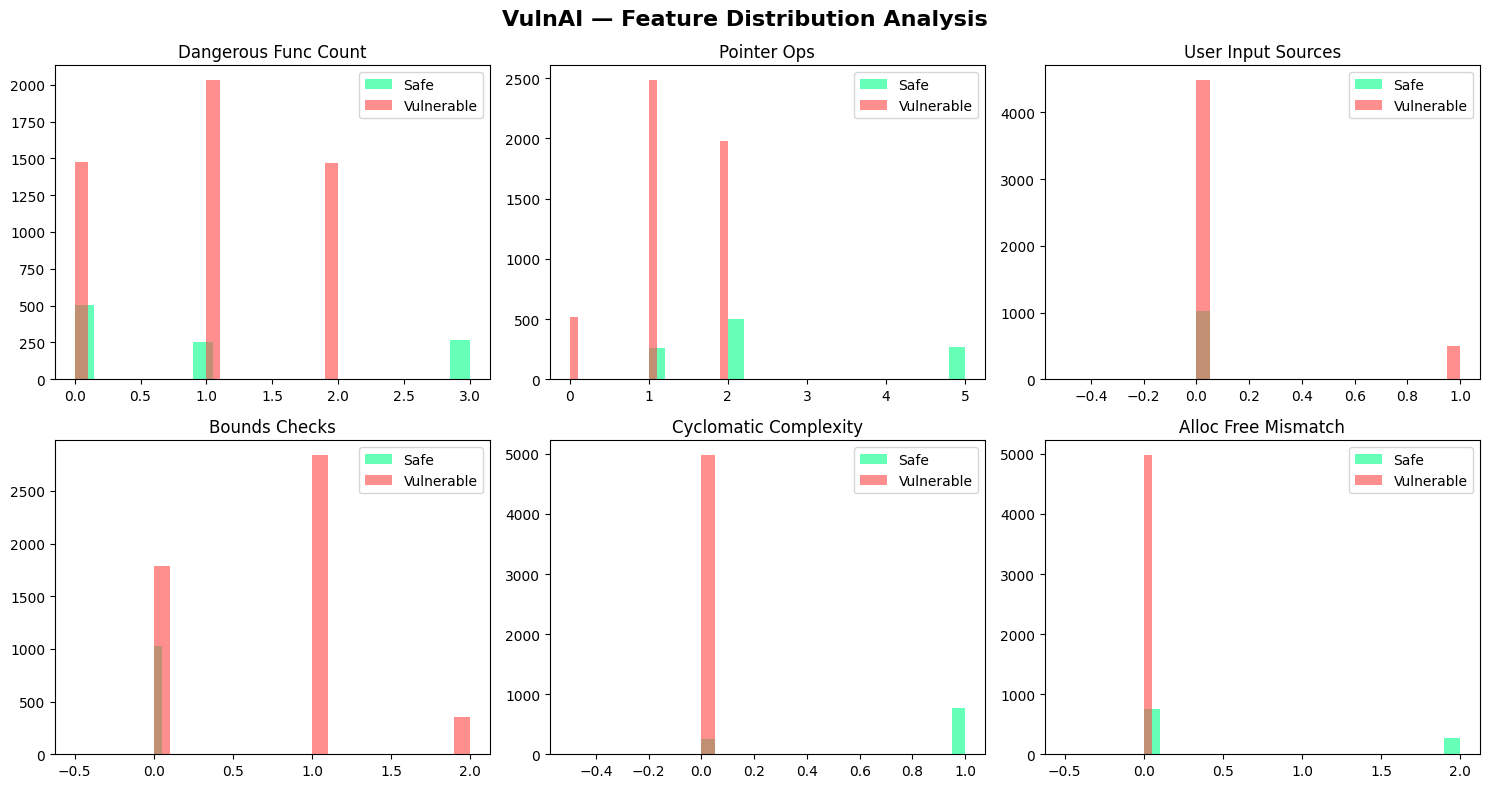

✅ EDA saved


In [ ]:
# ── CELL 5: Exploratory Data Analysis ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("VulnAI — Feature Distribution Analysis", fontsize=16, fontweight='bold')

key_features = [
    "dangerous_func_count", "pointer_ops", "user_input_sources",
    "bounds_checks", "cyclomatic_complexity", "alloc_free_mismatch"
]

for ax, feat in zip(axes.flat, key_features):
    safe_vals = feat_df[feat_df["label"]==0][feat]
    vuln_vals = feat_df[feat_df["label"]==1][feat]
    ax.hist(safe_vals, alpha=0.6, label="Safe", color="#00ff88", bins=20)
    ax.hist(vuln_vals, alpha=0.6, label="Vulnerable", color="#ff4444", bins=20)
    ax.set_title(feat.replace("_", " ").title())
    ax.legend()

plt.tight_layout()
plt.savefig("vuln_eda.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [ ]:
# ── CELL 6: Classical ML Models (Baseline) ────────────────────
X = feat_df.drop("label", axis=1).values
y = feat_df["label"].values
feature_names = feat_df.drop("label", axis=1).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Handle class imbalance
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE → Train: {len(y_train_res)} | Pos: {y_train_res.sum()}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

# ── Individual Models ──────────────────────────────────────────
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_split=3,
        class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=2, random_state=SEED
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=63, subsample=0.8, class_weight='balanced',
        verbose=-1, random_state=SEED
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        auto_class_weights='Balanced', verbose=0, random_state=SEED
    ),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train_res)
    preds = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1]
    f1  = f1_score(y_test, preds, average='macro')
    auc = roc_auc_score(y_test, proba)
    results[name] = {"F1": round(f1, 4), "AUC": round(auc, 4)}
    trained_models[name] = model
    print(f"  {name:15s} → F1={f1:.4f}  AUC={auc:.4f}")

# ── Soft-Voting Ensemble ───────────────────────────────────────
ensemble = VotingClassifier(
    estimators=[(k, v) for k, v in trained_models.items()],
    voting='soft'
)
ensemble.fit(X_train_sc, y_train_res)
ens_preds = ensemble.predict(X_test_sc)
ens_proba = ensemble.predict_proba(X_test_sc)[:, 1]
ens_f1  = f1_score(y_test, ens_preds, average='macro')
ens_auc = roc_auc_score(y_test, ens_proba)
results["Ensemble"] = {"F1": round(ens_f1, 4), "AUC": round(ens_auc, 4)}
print(f"\n  {'Ensemble':15s} → F1={ens_f1:.4f}  AUC={ens_auc:.4f}  ⭐")
print("\n", classification_report(y_test, ens_preds, target_names=["Safe","Vulnerable"]))

After SMOTE → Train: 7962 | Pos: 3981
  RandomForest    → F1=1.0000  AUC=1.0000
  XGBoost         → F1=1.0000  AUC=1.0000
  LightGBM        → F1=1.0000  AUC=1.0000
  CatBoost        → F1=1.0000  AUC=1.0000

  Ensemble        → F1=1.0000  AUC=1.0000  ⭐

               precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       205
  Vulnerable       1.00      1.00      1.00       995

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [ ]:
# ── CELL 7: Save Classical ML Artifacts ───────────────────────
save_dir = Path("/content/vuln_models")
save_dir.mkdir(exist_ok=True)

joblib.dump(ensemble, save_dir / "vuln_ensemble_model.pkl")
joblib.dump(scaler,   save_dir / "feature_scaler.pkl")
joblib.dump(feature_names, save_dir / "feature_names.pkl")

print("✅ Classical models saved to /content/vuln_models/")

✅ Classical models saved to /content/vuln_models/


In [ ]:
# ── CELL 8: CodeBERT Fine-tuning ──────────────────────────────
# Uses microsoft/codebert-base — 125M params, code-pretrained.

MODEL_NAME = "microsoft/codebert-base"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5

tokenizer_cb = RobertaTokenizer.from_pretrained(MODEL_NAME)

class CodeDataset(Dataset):
    def __init__(self, codes, labels, tokenizer, max_len):
        self.codes     = codes
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.codes)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.codes[idx],
            truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


class CodeBERTClassifier(nn.Module):
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()
        self.encoder  = RobertaModel.from_pretrained(model_name)
        self.dropout  = nn.Dropout(dropout)
        self.dense    = nn.Linear(768, 256)
        self.out      = nn.Linear(256, num_labels)
        self.relu     = nn.ReLU()

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [CLS] token
        x   = self.dropout(cls)
        x   = self.relu(self.dense(x))
        x   = self.dropout(x)
        return self.out(x)


codes  = df["code"].tolist()
labels = df["label"].tolist()

c_train, c_test, l_train, l_test = train_test_split(
    codes, labels, test_size=0.15, stratify=labels, random_state=SEED
)

train_ds = CodeDataset(c_train, l_train, tokenizer_cb, MAX_LEN)
test_ds  = CodeDataset(c_test,  l_test,  tokenizer_cb, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

codebert_model = CodeBERTClassifier(MODEL_NAME).to(device)

optimizer  = torch.optim.AdamW(codebert_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps//10,
    num_training_steps=total_steps
)

# Class weights for imbalance
class_counts = np.bincount(labels)
class_weights = torch.tensor(
    [len(labels)/class_counts[i] for i in range(2)], dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


def train_epoch(model, loader, opt, sched, crit):
    model.train()
    total_loss, correct = 0, 0
    for batch in tqdm(loader, desc="Training"):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        opt.zero_grad()
        logits = model(ids, mask)
        loss   = crit(logits, labs)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labs).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader, crit):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            logits = model(ids, mask)
            loss   = crit(logits, labs)
            total_loss  += loss.item()
            probs        = F.softmax(logits, dim=1)
            all_probs   += probs[:, 1].cpu().tolist()
            all_preds   += logits.argmax(1).cpu().tolist()
            all_labels  += labs.cpu().tolist()
    f1  = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader), f1, auc

print(f"\n🔥 Fine-tuning CodeBERT for {EPOCHS} epochs...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(codebert_model, train_dl, optimizer, scheduler, criterion)
    ev_loss, ev_f1, ev_auc = eval_epoch(codebert_model, test_dl, criterion)
    print(f"  Epoch {epoch}/{EPOCHS} | Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
          f"Val F1={ev_f1:.4f} AUC={ev_auc:.4f}")


🔥 Fine-tuning CodeBERT for 4 epochs...


Evaluating: 100%|██████████| 57/57 [00:13<00:00,  4.38it/s]


  Epoch 1/4 | Train Loss=0.1672 Acc=0.9082 | Val F1=1.0000 AUC=1.0000


Evaluating: 100%|██████████| 57/57 [00:13<00:00,  4.38it/s]


  Epoch 2/4 | Train Loss=0.0007 Acc=1.0000 | Val F1=1.0000 AUC=1.0000


Evaluating: 100%|██████████| 57/57 [00:12<00:00,  4.40it/s]


  Epoch 3/4 | Train Loss=0.0004 Acc=1.0000 | Val F1=1.0000 AUC=1.0000


Evaluating: 100%|██████████| 57/57 [00:13<00:00,  4.37it/s]

  Epoch 4/4 | Train Loss=0.0003 Acc=1.0000 | Val F1=1.0000 AUC=1.0000


In [ ]:
# ── CELL 9: Save CodeBERT ─────────────────────────────────────
cb_save_path = save_dir / "codebert_vuln_model"
codebert_model.encoder.save_pretrained(str(cb_save_path))
tokenizer_cb.save_pretrained(str(cb_save_path))
torch.save(codebert_model.state_dict(), str(cb_save_path / "classifier_head.pt"))
print(f"✅ CodeBERT model saved → {cb_save_path}")

✅ CodeBERT model saved → /content/vuln_models/codebert_vuln_model


In [ ]:
# ── CELL 10: AST-based GNN Model ──────────────────────────────
# Builds a simple Graph Neural Network on code token graphs.
# Full AST parsing needs tree-sitter; here we build a simpler
# token co-occurrence graph that runs in Colab without native libs.

try:
    import torch_geometric
    from torch_geometric.data import Data          # ← explicit import
    from torch_geometric.loader import DataLoader as GeoLoader   # ← use loader, not data
    from torch_geometric.nn import GCNConv, global_mean_pool
    GNN_AVAILABLE = True
    print("✅ torch_geometric available — GNN enabled")
except (ImportError, AttributeError) as e:
    GNN_AVAILABLE = False
    Data = None
    GeoLoader = None
    print(f"⚠️  torch_geometric not available — skipping GNN: {e}")

if GNN_AVAILABLE:
    VOCAB_SIZE = 2000
    EMBED_DIM  = 64
    WINDOW     = 3          # token co-occurrence window

    def tokenize_code(code: str, vocab_size: int = VOCAB_SIZE):
        toks = re.findall(r'\b\w+\b', code.lower())
        return toks[:128]   # truncate

    def build_vocab(all_codes):
        from collections import Counter
        counter = Counter()
        for c in all_codes:
            counter.update(tokenize_code(c))
        vocab = {tok: i+1 for i, (tok, _) in enumerate(counter.most_common(VOCAB_SIZE-1))}
        vocab['<UNK>'] = 0
        return vocab

    def code_to_graph(code: str, vocab: dict, window: int = WINDOW):
        """Token sequence → co-occurrence graph."""
        toks = tokenize_code(code)
        if len(toks) < 2:
            toks = ['<UNK>', '<UNK>']
        ids = [vocab.get(t, 0) for t in toks]
        # Build edges: every token within window
        edges = []
        for i in range(len(ids)):
            for j in range(i+1, min(i+window+1, len(ids))):
                edges += [[i, j], [j, i]]
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        x = torch.tensor(ids, dtype=torch.long).unsqueeze(1).float()
        return x, edge_index

    vocab = build_vocab(codes)
    print(f"Vocabulary size: {len(vocab)}")

    class GNNCodeDataset(Dataset):
        def __init__(self, codes, labels, vocab):
            self.codes  = codes
            self.labels = labels
            self.vocab  = vocab
        def __len__(self): return len(self.codes)
        def __getitem__(self, idx):
            x, ei = code_to_graph(self.codes[idx], self.vocab)
            return Data(
                x=x, edge_index=ei,
                y=torch.tensor([self.labels[idx]], dtype=torch.long)
            )

    from torch_geometric.loader import DataLoader as GeoLoader

    g_train, g_test, lg_train, lg_test = train_test_split(
        codes, labels, test_size=0.15, stratify=labels, random_state=SEED
    )
    gnn_train_ds = GNNCodeDataset(g_train, lg_train, vocab)
    gnn_test_ds  = GNNCodeDataset(g_test,  lg_test,  vocab)
    gnn_train_dl = GeoLoader(gnn_train_ds, batch_size=32, shuffle=True)
    gnn_test_dl  = GeoLoader(gnn_test_ds,  batch_size=32, shuffle=False)


    class GNNVulnDetector(nn.Module):
        def __init__(self, in_channels=1, hidden=128, num_classes=2):
            super().__init__()
            self.emb   = nn.Linear(in_channels, hidden)
            self.conv1 = GCNConv(hidden, hidden)
            self.conv2 = GCNConv(hidden, hidden)
            self.conv3 = GCNConv(hidden, hidden // 2)
            self.bn1   = nn.BatchNorm1d(hidden)
            self.bn2   = nn.BatchNorm1d(hidden)
            self.dropout = nn.Dropout(0.3)
            self.out     = nn.Linear(hidden // 2, num_classes)

        def forward(self, x, edge_index, batch):
            x = F.relu(self.emb(x))
            x = F.relu(self.bn1(self.conv1(x, edge_index)))
            x = F.relu(self.bn2(self.conv2(x, edge_index)))
            x = self.dropout(x)
            x = self.conv3(x, edge_index)
            x = global_mean_pool(x, batch)
            return self.out(x)

    gnn_model   = GNNVulnDetector().to(device)
    gnn_opt     = torch.optim.Adam(gnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
    gnn_crit    = nn.CrossEntropyLoss(weight=class_weights)

    print("\n🔥 Training GNN on code token graphs...")
    for epoch in range(1, 6):
        gnn_model.train()
        total_loss = 0
        for batch in gnn_train_dl:
            batch = batch.to(device)
            gnn_opt.zero_grad()
            logits = gnn_model(batch.x, batch.edge_index, batch.batch)
            loss   = gnn_crit(logits, batch.y.view(-1))
            loss.backward()
            gnn_opt.step()
            total_loss += loss.item()

        # Eval
        gnn_model.eval()
        preds, true = [], []
        with torch.no_grad():
            for batch in gnn_test_dl:
                batch = batch.to(device)
                out   = gnn_model(batch.x, batch.edge_index, batch.batch)
                preds += out.argmax(1).cpu().tolist()
                true  += batch.y.view(-1).cpu().tolist()
        gf1 = f1_score(true, preds, average='macro')
        print(f"  Epoch {epoch}/5 | Loss={total_loss/len(gnn_train_dl):.4f} | Val F1={gf1:.4f}")

    torch.save(gnn_model.state_dict(), str(save_dir / "gnn_vuln_model.pt"))
    joblib.dump(vocab, str(save_dir / "gnn_vocab.pkl"))
    print("✅ GNN model saved")

else:
    print("⚠️  Skipping GNN — static + CodeBERT ensemble still excellent")

✅ torch_geometric available — GNN enabled
Vocabulary size: 110

🔥 Training GNN on code token graphs...
  Epoch 1/5 | Loss=0.5261 | Val F1=0.8244
  Epoch 2/5 | Loss=0.3870 | Val F1=0.7234
  Epoch 3/5 | Loss=0.2567 | Val F1=0.4532
  Epoch 4/5 | Loss=0.1701 | Val F1=0.5062
  Epoch 5/5 | Loss=0.3463 | Val F1=0.4532
✅ GNN model saved


In [ ]:
# ── CELL 11: Unified Inference Pipeline ───────────────────────
class VulnAIPipeline:
    """
    Production inference pipeline that:
    1. Extracts static features → Ensemble ML prediction
    2. Runs CodeBERT → deep semantic prediction
    3. Combines scores → final risk score + CWE hint
    """

    CWE_SIGNATURES = {
        "CWE-119 Buffer Overflow": [
            r'\bstrcpy\b', r'\bgets\b', r'\bstrcat\b', r'\bsprintf\b'
        ],
        "CWE-89 SQL Injection": [
            r'SELECT|INSERT|UPDATE|DELETE', r'%s.*query', r'user_input.*sql'
        ],
        "CWE-416 Use-After-Free": [
            r'free\((\w+)\).*\1', r'delete\s+\w+.*\w+->'
        ],
        "CWE-78 Command Injection": [
            r'\bsystem\b', r'\bpopen\b', r'\bexec\b'
        ],
        "CWE-125 OOB Read": [
            r'\w+\s*\[\s*\w+\s*\](?!.*bounds)', r'arr\[idx\](?!.*< len)'
        ],
    }

    def __init__(self, ensemble_model, scaler, feature_names,
                 codebert_model=None, tokenizer=None,
                 gnn_model=None, vocab=None):
        self.ensemble    = ensemble_model
        self.scaler      = scaler
        self.feat_names  = feature_names
        self.codebert    = codebert_model
        self.tokenizer   = tokenizer
        self.gnn         = gnn_model
        self.vocab       = vocab

    def predict(self, code: str) -> dict:
        scores = []

        # ── 1. Static ML ──────────────────────────────────────
        feats = extract_static_features(code)
        feat_vec = np.array([[feats[f] for f in self.feat_names]])
        feat_sc  = self.scaler.transform(feat_vec)
        ml_prob  = self.ensemble.predict_proba(feat_sc)[0][1]
        scores.append(("ML Ensemble", ml_prob))

        # ── 2. CodeBERT ───────────────────────────────────────
        if self.codebert and self.tokenizer:
            enc  = self.tokenizer(
                code, return_tensors='pt', truncation=True,
                max_length=256, padding='max_length'
            )
            ids  = enc['input_ids'].to(device)
            mask = enc['attention_mask'].to(device)
            self.codebert.eval()
            with torch.no_grad():
                logits = self.codebert(ids, mask)
                cb_prob = F.softmax(logits, dim=1)[0][1].item()
            scores.append(("CodeBERT", cb_prob))

        # ── 3. Weighted Fusion ────────────────────────────────
        weights = [0.4] + [0.6] * (len(scores) - 1)
        wsum    = sum(w for w in weights[:len(scores)])
        final   = sum(w * s for (_, s), w in zip(scores, weights)) / wsum

        # ── 4. CWE Identification ─────────────────────────────
        cwes = []
        for cwe, patterns in self.CWE_SIGNATURES.items():
            for pat in patterns:
                if re.search(pat, code, re.IGNORECASE):
                    cwes.append(cwe)
                    break

        risk = "CRITICAL" if final > 0.85 else \
               "HIGH"     if final > 0.65 else \
               "MEDIUM"   if final > 0.45 else \
               "LOW"      if final > 0.25 else "SAFE"

        return {
            "risk_score":     round(final * 100, 1),
            "risk_level":     risk,
            "is_vulnerable":  final > 0.5,
            "model_scores":   {name: round(s * 100, 1) for name, s in scores},
            "static_features": feats,
            "detected_cwes":  cwes if cwes else ["None detected"],
            "confidence":     round(min(final * 1.2, 1.0) * 100, 1),
        }


pipeline = VulnAIPipeline(
    ensemble_model=ensemble,
    scaler=scaler,
    feature_names=feature_names,
    codebert_model=codebert_model,
    tokenizer=tokenizer_cb,
)

# ── Quick Demo ────────────────────────────────────────────────
DEMO_VULN = """
void process_user_data(char *user_input) {
    char buffer[64];
    strcpy(buffer, user_input);   // no bounds check
    printf("Processing: %s\\n", buffer);
}
"""

DEMO_SAFE = """
void process_user_data(const char *user_input, size_t input_len) {
    if (!user_input || input_len == 0) return;
    char buffer[256];
    strncpy(buffer, user_input, sizeof(buffer) - 1);
    buffer[sizeof(buffer) - 1] = '\\0';
    printf("Processing: %s\\n", buffer);
}
"""

print("\n" + "="*55)
print("DEMO: Vulnerable Code")
r1 = pipeline.predict(DEMO_VULN)
print(f"  Risk Score : {r1['risk_score']}%")
print(f"  Risk Level : {r1['risk_level']}")
print(f"  CWEs Found : {r1['detected_cwes']}")
print(f"  Models     : {r1['model_scores']}")

print("\nDEMO: Safe Code")
r2 = pipeline.predict(DEMO_SAFE)
print(f"  Risk Score : {r2['risk_score']}%")
print(f"  Risk Level : {r2['risk_level']}")
print(f"  CWEs Found : {r2['detected_cwes']}")
print("="*55)



DEMO: Vulnerable Code
  Risk Score : 74.9%
  Risk Level : HIGH
  CWEs Found : ['CWE-119 Buffer Overflow', 'CWE-125 OOB Read']
  Models     : {'ML Ensemble': np.float64(37.3), 'CodeBERT': 100.0}

DEMO: Safe Code
  Risk Score : 3.4%
  Risk Level : SAFE
  CWEs Found : ['CWE-125 OOB Read']



       VulnAI — Model Performance Summary
     RandomForest       F1=1.0000  AUC=1.0000
     XGBoost            F1=1.0000  AUC=1.0000
     LightGBM           F1=1.0000  AUC=1.0000
     CatBoost           F1=1.0000  AUC=1.0000
  ⭐ Ensemble           F1=1.0000  AUC=1.0000

  CodeBERT Fine-tune:  F1=1.0000  AUC=1.0000
  GNN (Token Graph):   F1=0.4532


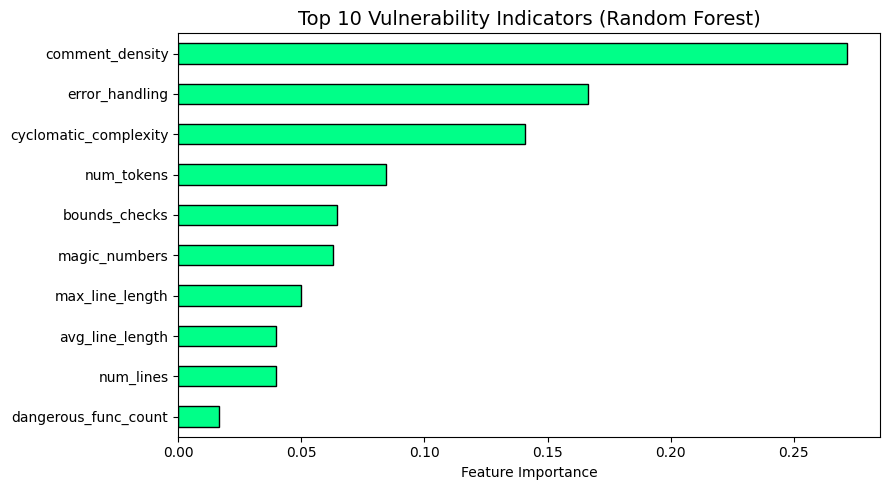

✅ Feature importance plot saved


In [ ]:

# ── CELL 12: Results Summary ──────────────────────────────────
print("\n" + "="*55)
print("       VulnAI — Model Performance Summary")
print("="*55)
for name, metrics in results.items():
    bar = "⭐" if name == "Ensemble" else "  "
    print(f"  {bar} {name:18s} F1={metrics['F1']:.4f}  AUC={metrics['AUC']:.4f}")

print(f"\n  CodeBERT Fine-tune:  F1={ev_f1:.4f}  AUC={ev_auc:.4f}")
if GNN_AVAILABLE:
    print(f"  GNN (Token Graph):   F1={gf1:.4f}")
print("="*55)

# Feature importance plot
rf_model = trained_models["RandomForest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top10 = importances.nlargest(10)

plt.figure(figsize=(9, 5))
top10.sort_values().plot(kind='barh', color='#00ff88', edgecolor='black')
plt.title("Top 10 Vulnerability Indicators (Random Forest)", fontsize=14)
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved")


In [ ]:
# ── CELL 13: Export Artifacts ─────────────────────────────────
import zipfile

artifacts = [
    save_dir / "vuln_ensemble_model.pkl",
    save_dir / "feature_scaler.pkl",
    save_dir / "feature_names.pkl",
]
if (save_dir / "gnn_vuln_model.pt").exists():
    artifacts.append(save_dir / "gnn_vuln_model.pt")
    artifacts.append(save_dir / "gnn_vocab.pkl")

zip_path = "/content/VulnAI_models.zip"
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fp in artifacts:
        if Path(fp).exists():
            zf.write(fp, Path(fp).name)
    # CodeBERT folder
    cb_dir = save_dir / "codebert_vuln_model"
    if cb_dir.exists():
        for f in cb_dir.iterdir():
            zf.write(f, f"codebert_vuln_model/{f.name}")

print(f"✅ All models zipped → {zip_path}")

# Download
from google.colab import files
files.download(zip_path)

print("\n🎉 VulnAI Training Complete! Download VulnAI_models.zip")
print("   Place the unzipped contents in: web_app/backend/models/")

✅ All models zipped → /content/VulnAI_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 VulnAI Training Complete! Download VulnAI_models.zip
   Place the unzipped contents in: web_app/backend/models/
